# Explanatory Data Analysis

The objective of this notebook is to explore the dataset and identify patterns, relationships, and trends associated with customer churn. To keep the analysis organized, this notebook is structured around a series of business questions. Each section investigates a specific aspect of customer churn using visualizations and descriptive statistics. The findings from each analysis are summarized and interpreted before moving on to the next question.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/telco_customer_churn_cleaned.csv")

## 1. What is the distribution of the target variable?

This helps identify whether the dataset is balanced or if churn represents a minority class.

In [2]:
df["Churn Label"].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

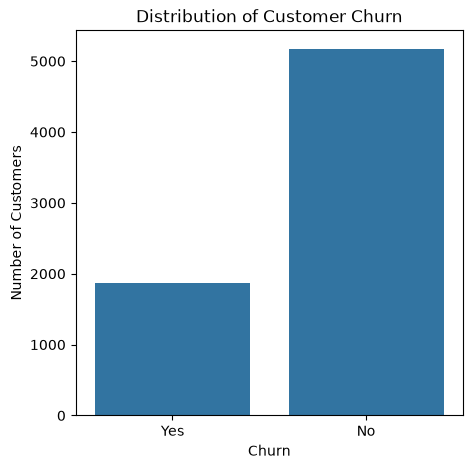

In [3]:
plt.figure(figsize=(5, 5))

ax = sns.countplot(
    data=df,
    x="Churn Label"
)

ax.set_title("Distribution of Customer Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")

plt.show()

The target variable is moderately imbalanced (churned customers represent a smaller proportion of the dataset). This imbalance should be considered during model evaluation, as accuracy alone may provide a misleading view of model performance.

## 2. Does customer tenure influence churn?

It is reasonable to expect that long-term customers are more loyal than newly acquired ones. This section investigates whether customer tenure is associated with customer churn.

In [10]:
df.groupby("Churn Label")["Tenure Months"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


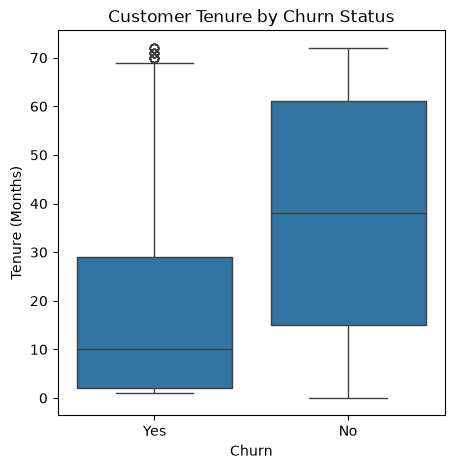

In [12]:
plt.figure(figsize=(5, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

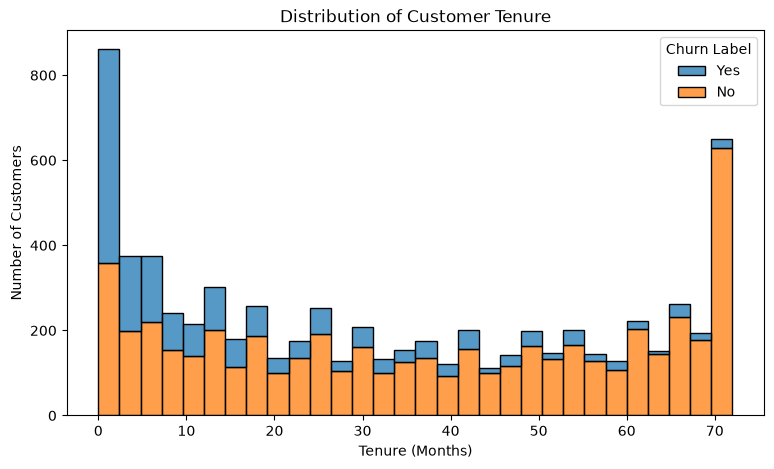

In [26]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="Tenure Months",
    hue="Churn Label",
    bins=30,
    multiple="stack"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

Customers who churn tend to have considerably shorter tenure than customers who remain with the company. This suggests that the probability of churn is highest during the early stages of the customer relationship.

## 3. Does monthly charge influence churn?

In [27]:
df.groupby("Churn Label")["Monthly Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


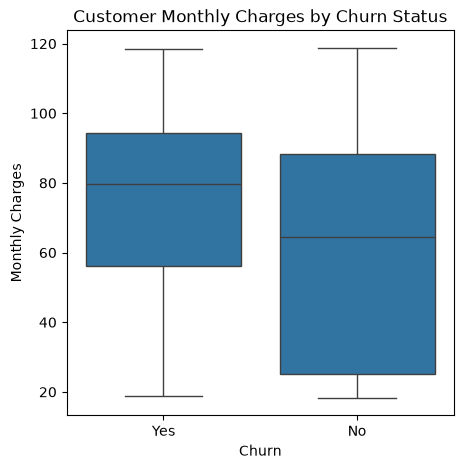

In [29]:
plt.figure(figsize=(5, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Customer Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

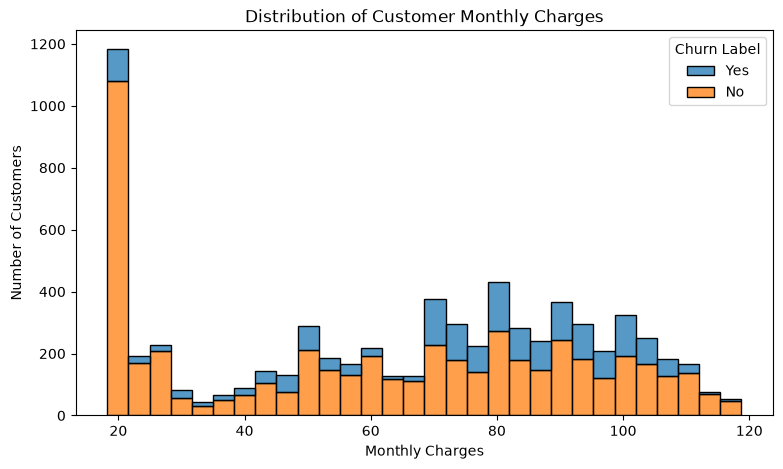

In [30]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="Monthly Charges",
    hue="Churn Label",
    bins=30,
    multiple="stack"
)

plt.title("Distribution of Customer Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

Customers who churn tend to have higher monthly charges than those who remain with the company. Although the distributions overlap considerably, higher monthly fees appear to be associated with an increased likelihood of churn.

## 4. Does total charge influence churn?

In [31]:
df.groupby("Churn Label")["Total Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


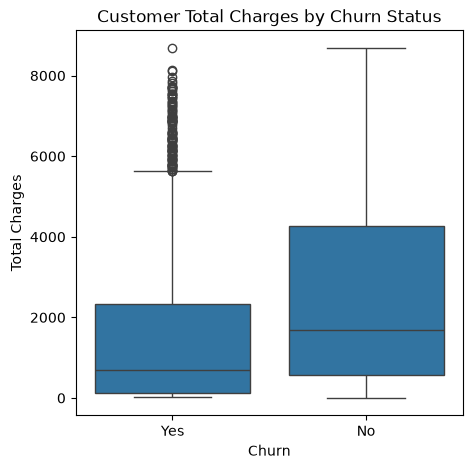

In [32]:
plt.figure(figsize=(5, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Total Charges"
)

plt.title("Customer Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

The box plot shows that customers who churn generally have lower Total Charges than those who remain with the company. At the same time, several high-value outliers are visible among churned customers, suggesting that a small number of long-term customers also decide to leave despite their substantial investment.

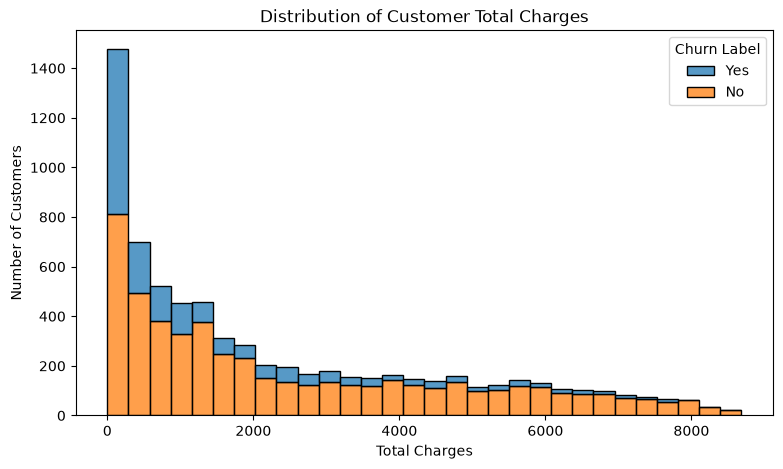

In [33]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="Total Charges",
    hue="Churn Label",
    bins=30,
    multiple="stack"
)

plt.title("Distribution of Customer Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

The histogram reveals a strong concentration of churned customers with very low Total Charges. This pattern closely resembles the distribution observed for customer tenure, suggesting that many customers decide to leave shortly after joining the service. As total charges increase, the proportion of churned customers gradually decreases.

One possible explanation is that some customers evaluate the service during the first months and decide not to continue. However, this interpretation remains a hypothesis and would require additional behavioral or survey data to be confirmed.

Possible business recommendations

Improve the onboarding process.
Offer discounts or incentives during the first months of the subscription.

### Who are the long-term customers that still churned?

In [ ]:
high_value_churn = df[
    (df["Churn Label"] == "Yes")
    &
    (df["Total Charges"] > 6000)
]

high_value_churn

## 5. Does contract type influence churn?

Contract type determines how committed a customer is to the service. Customers with long-term contracts may be less likely to churn than customers who can cancel at any time.

In [43]:
contract_churn = pd.crosstab(
    index=df["Contract"],
    columns=df["Churn Label"],
    normalize="index"
)

contract_churn_rate = (
    contract_churn["Yes"]
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="Churn Rate")
)

contract_churn_rate

,Contract,Churn Rate
0,Month-to-month,42.709677
1,One year,11.269518
2,Two year,2.831858


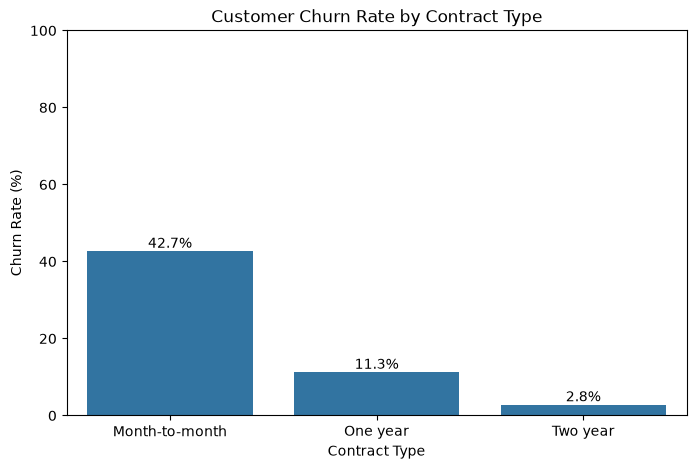

In [44]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=contract_churn_rate,
    x="Contract",
    y="Churn Rate"
)

ax.set_title("Customer Churn Rate by Contract Type")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

## 6. Does internet service type influence churn?

In [9]:
internet_service_churn = pd.crosstab(
    index=df["Internet Service"],
    columns=df["Churn Label"],
    normalize="index"
)

internet_service_churn_rate = (
    internet_service_churn["Yes"]
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="Churn Rate")
)

internet_service_churn_rate

,Internet Service,Churn Rate
0,Fiber optic,41.892765
1,DSL,18.959108
2,No,7.404980


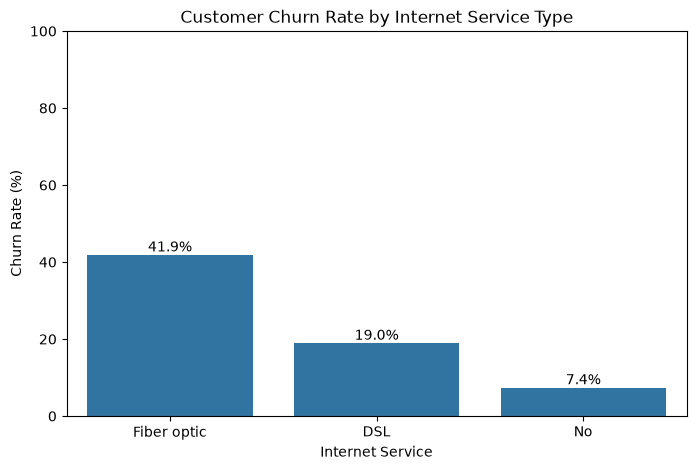

In [10]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=internet_service_churn_rate,
    x="Internet Service",
    y="Churn Rate"
)

ax.set_title("Customer Churn Rate by Internet Service Type")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

Customers with fiber optic internet service show a substantially higher churn rate compared to customers using DSL or no internet service. However, further analysis is needed to determine whether fiber optic service itself is associated with churn or whether this pattern is related to other factors such as monthly charges or contract type.

## 7. Does having technical support influence churn?

In [14]:
tech_support_churn = pd.crosstab(
    index=df["Tech Support"],
    columns=df["Churn Label"],
    normalize="index"
)

tech_support_churn_rate = (
    tech_support_churn["Yes"]
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="Churn Rate")
)


tech_support_churn_rate

,Tech Support,Churn Rate
0,No,41.635474
1,Yes,15.166341
2,No internet service,7.404980


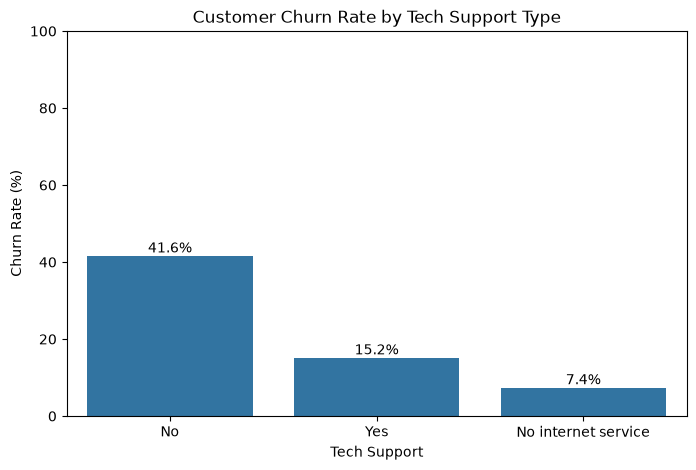

In [15]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=tech_support_churn_rate,
    x="Tech Support",
    y="Churn Rate"
)

ax.set_title("Customer Churn Rate by Tech Support Type")
ax.set_xlabel("Tech Support")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

Customers without tech support show a considerably higher churn rate than customers with tech support. Interestingly, the churn rates observed for tech support categories are similar to those observed for internet service types, raising the question of whether these two features are related.

In [16]:
pd.crosstab(
    df["Internet Service"],
    df["Tech Support"],
    normalize="index"
) * 100

Tech Support,No,No internet service,Yes
Internet Service,,,
DSL,51.342420,0.0,48.657580
Fiber optic,72.028424,0.0,27.971576
No,0.000000,100.0,0.000000


Among DSL customers, tech support adoption is approximately evenly split, with 48.7% having tech support. In contrast, only 28.0% of fiber optic customers have tech support, while 72.0% do not. This suggests a relationship between internet service type and tech support subscription that may be worth investigating further.

## 8. Does Online Security influence customer churn?

In [18]:
online_security_churn = pd.crosstab(
    index=df["Online Security"],
    columns=df["Churn Label"],
    normalize="index"
)

online_security_churn_rate = (
    online_security_churn["Yes"]
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="Churn Rate")
)


online_security_churn_rate

,Online Security,Churn Rate
0,No,41.766724
1,Yes,14.611194
2,No internet service,7.404980


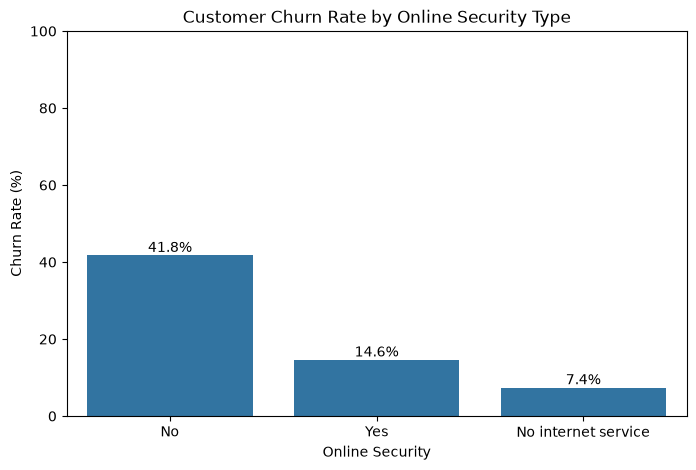

In [19]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=online_security_churn_rate,
    x="Online Security",
    y="Churn Rate"
)

ax.set_title("Customer Churn Rate by Online Security Type")
ax.set_xlabel("Online Security")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

The churn rates are again very similar to those observed for Tech Support and Internet Service, suggesting that these features may be related.

In [20]:
pd.crosstab(
    df["Internet Service"],
    df["Online Security"],
    normalize="index"
) * 100

Online Security,No,No internet service,Yes
Internet Service,,,
DSL,51.259810,0.0,48.740190
Fiber optic,72.900517,0.0,27.099483
No,0.000000,100.0,0.000000


In [21]:
pd.crosstab(
    df["Tech Support"],
    df["Online Security"],
    normalize="index"
) * 100

Online Security,No,No internet service,Yes
Tech Support,,,
No,73.509934,0.0,26.490066
No internet service,0.000000,100.0,0.000000
Yes,46.232877,0.0,53.767123


Fiber optic customers subscribe to additional services such as Tech Support and Online Security less frequently than DSL customers. Furthermore, customers without Tech Support are also more likely to be without Online Security. These findings suggest that the features are related and should be investigated together in the multivariate analysis.

## 9. Does payment method influence churn?

In [4]:
payment_churn = pd.crosstab(
    index=df["Payment Method"],
    columns=df["Churn Label"],
    normalize="index"
)

payment_churn_rate = (
    payment_churn["Yes"]
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="Churn Rate")
)

payment_churn_rate

,Payment Method,Churn Rate
0,Electronic check,45.285412
1,Mailed check,19.106700
2,Bank transfer (automatic),16.709845
3,Credit card (automatic),15.243101


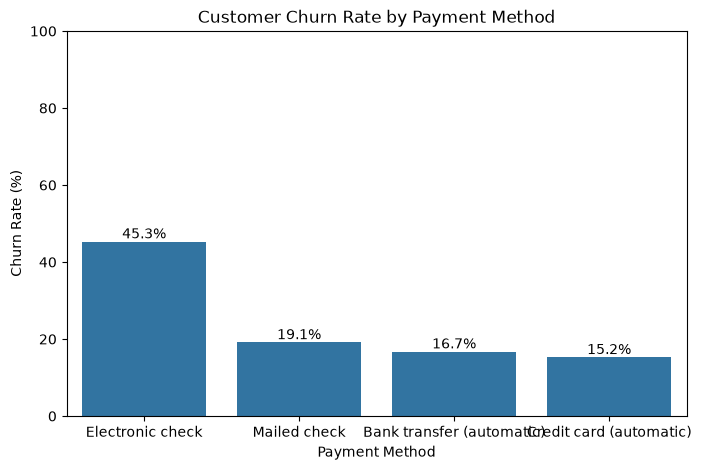

In [5]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=payment_churn_rate,
    x="Payment Method",
    y="Churn Rate"
)

ax.set_title("Customer Churn Rate by Payment Method")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

Customers paying by electronic check show a substantially higher churn rate than customers using other payment methods.

## 10. Do partner/dependents influence churn?

In [9]:
partner_churn = pd.crosstab(
    index=df["Partner"],
    columns=df["Churn Label"],
    normalize="index"
)

partner_churn_rate = (
    partner_churn["Yes"]
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="Churn Rate")
)

partner_churn_rate

,Partner,Churn Rate
0,No,32.957979
1,Yes,19.664903


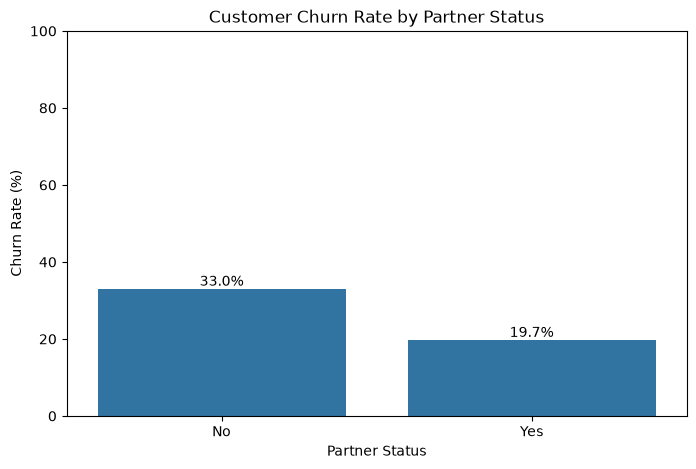

In [10]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=partner_churn_rate,
    x="Partner",
    y="Churn Rate"
)

ax.set_title("Customer Churn Rate by Partner Status")
ax.set_xlabel("Partner Status")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

Customers without a partner show a higher churn rate than customers with a partner.